# 05 — Final Location Feature Engineering

This notebook keeps the original AVM-safe Week 5 feature set and adds only the location features that produced a meaningful validation improvement.

Retained engineered features:

- Smoothed historical price per square foot by postal code, MLS area, city, and high-school district.
- Historical sale count for each of those location groups.
- A value anchor equal to local historical price per square foot multiplied by living area.
- A 25-nearest-comparable price-per-square-foot estimate, comparable distance, and value anchor.

All price-based features are leakage-safe: training rows receive out-of-fold values, while validation rows use mappings and comparable sales fitted only on the training set. `ListPrice`, `OriginalListPrice`, and `DaysOnMarket` remain excluded. The May 2026 test set is not evaluated.

In [1]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

## Load the agreed chronological split

In [2]:
DATA_FILE = Path("data/week5_unstandardized_model_data.csv")
RESULTS_FILE = Path("data/week6_feature_engineering_validation_results.csv")
IMPORTANCE_FILE = Path("data/week6_feature_engineering_importance.csv")
COMPARISON_PLOT_FILE = Path("data/week6_feature_engineering_comparison.png")
IMPORTANCE_PLOT_FILE = Path("data/week6_feature_engineering_importance.png")
MODEL_FILE = Path("data/week6_best_feature_engineering_validation_model.joblib")

TRAIN_MONTHS = pd.period_range("2025-02", "2026-01", freq="M").astype(str).tolist()
VALIDATION_MONTHS = pd.period_range("2026-02", "2026-04", freq="M").astype(str).tolist()
TEST_MONTHS = ["2026-05"]
RANDOM_STATE = 42

df = pd.read_csv(DATA_FILE, low_memory=False)
expected_months = {
    "train": TRAIN_MONTHS,
    "validation": VALIDATION_MONTHS,
    "test": TEST_MONTHS,
}
for split_name, expected in expected_months.items():
    actual = sorted(df.loc[df["split"] == split_name, "close_month"].unique())
    assert actual == expected, (split_name, actual, expected)

train = df[df["split"] == "train"].copy()
validation = df[df["split"] == "validation"].copy()

# Match the Week 5 trimmed population. This boundary is learned from training only.
UPPER_CUTOFF = train["ClosePrice"].quantile(0.995)
train = train[train["ClosePrice"] <= UPPER_CUTOFF].copy()
validation = validation[validation["ClosePrice"] <= UPPER_CUTOFF].copy()

print(f"Training rows:   {len(train):,} ({TRAIN_MONTHS[0]} through {TRAIN_MONTHS[-1]})")
print(f"Validation rows: {len(validation):,} ({VALIDATION_MONTHS[0]} through {VALIDATION_MONTHS[-1]})")
print(f"Training-only upper cutoff: ${UPPER_CUTOFF:,.0f}")
print("May 2026 remains untouched.")

Training rows:   128,797 (2025-02 through 2026-01)
Validation rows: 31,554 (2026-02 through 2026-04)
Training-only upper cutoff: $8,200,000
May 2026 remains untouched.


## Original feature set

The baseline below is unchanged from the Week 5 AVM-safe comparison.

In [3]:
BASE_NUMERIC = [
    "Latitude", "Longitude", "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger", "HomeAge", "Stories",
    "GarageSpaces", "ParkingTotal", "AssociationFee",
    "LotSizeSquareFeet", "LotSizeAcres", "MainLevelBedrooms",
]
BASE_BOOLEAN = [
    "ViewYN", "WaterfrontYN", "PoolPrivateYN", "AttachedGarageYN",
    "FireplaceYN", "NewConstructionYN",
]
BASE_CATEGORICAL = [
    "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
    "HighSchoolDistrict", "Levels",
]
PROHIBITED_FEATURES = {"ListPrice", "OriginalListPrice", "DaysOnMarket"}
assert PROHIBITED_FEATURES.isdisjoint(BASE_NUMERIC + BASE_BOOLEAN + BASE_CATEGORICAL)

for frame in (train, validation):
    for column in BASE_CATEGORICAL:
        frame[column] = frame[column].fillna("Unknown").astype(str)

pd.DataFrame({
    "feature_type": ["numeric", "boolean", "categorical"],
    "original_feature_count": [len(BASE_NUMERIC), len(BASE_BOOLEAN), len(BASE_CATEGORICAL)],
})

,feature_type,original_feature_count
0,numeric,14
1,boolean,6
2,categorical,6


## Administrative location priors

For postal code, MLS area, city, and high-school district, the notebook creates three features:

- `PriorPpsf_*`: smoothed historical price per square foot.
- `PriorLogCount_*`: log historical sale count, which tells the model how much evidence supports the estimate.
- `PriorValue_*`: historical local PPSF multiplied by the property's living area.

Smoothing pulls small groups toward the training-wide median. Five-fold out-of-fold construction prevents each training sale from contributing to its own prior.

In [4]:
PRIOR_GROUPS = ["PostalCode", "MLSAreaMajor", "City", "HighSchoolDistrict"]
PRIOR_SMOOTHING = 40


def safe_ppsf(frame):
    values = frame["ClosePrice"] / frame["LivingArea"].where(frame["LivingArea"] > 0)
    return values.where(values.between(10, 5_000))


def fit_smoothed_prior(source, group_column, smoothing=PRIOR_SMOOTHING):
    work = pd.DataFrame({
        "group": source[group_column].astype(str),
        "ppsf": safe_ppsf(source),
    }).dropna()
    global_prior = work["ppsf"].median()
    stats = work.groupby("group")["ppsf"].agg(["median", "count"])
    stats["prior"] = (
        stats["median"] * stats["count"] + global_prior * smoothing
    ) / (stats["count"] + smoothing)
    return stats["prior"], stats["count"], global_prior


def add_administrative_priors(train_frame, validation_frame, n_splits=5):
    train_out = train_frame.copy()
    validation_out = validation_frame.copy()
    folds = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for group_column in PRIOR_GROUPS:
        ppsf_column = f"PriorPpsf_{group_column}"
        count_column = f"PriorLogCount_{group_column}"
        value_column = f"PriorValue_{group_column}"
        train_out[ppsf_column] = np.nan
        train_out[count_column] = np.nan

        for fit_positions, holdout_positions in folds.split(train_frame):
            fit_rows = train_frame.iloc[fit_positions]
            holdout_index = train_frame.index[holdout_positions]
            prior_map, count_map, global_prior = fit_smoothed_prior(fit_rows, group_column)
            keys = train_frame.loc[holdout_index, group_column].astype(str)
            train_out.loc[holdout_index, ppsf_column] = (
                keys.map(prior_map).fillna(global_prior).to_numpy()
            )
            train_out.loc[holdout_index, count_column] = np.log1p(
                keys.map(count_map).fillna(0).to_numpy()
            )

        prior_map, count_map, global_prior = fit_smoothed_prior(train_frame, group_column)
        validation_keys = validation_frame[group_column].astype(str)
        validation_out[ppsf_column] = validation_keys.map(prior_map).fillna(global_prior)
        validation_out[count_column] = np.log1p(
            validation_keys.map(count_map).fillna(0)
        )
        train_out[value_column] = train_out[ppsf_column] * train_out["LivingArea"]
        validation_out[value_column] = (
            validation_out[ppsf_column] * validation_out["LivingArea"]
        )

    return train_out, validation_out


train_features, validation_features = add_administrative_priors(train, validation)
ADMIN_PRIOR_FEATURES = [
    feature
    for group in PRIOR_GROUPS
    for feature in (
        f"PriorPpsf_{group}", f"PriorLogCount_{group}", f"PriorValue_{group}"
    )
]

train_features[ADMIN_PRIOR_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
PriorPpsf_PostalCode,"128,797.0000",556.1348,205.7449,261.9034,394.9593,532.6033,663.3842,"1,462.4204"
PriorLogCount_PostalCode,"128,797.0000",4.9623,0.8534,0.0000,4.5433,5.0999,5.5053,6.6490
PriorValue_PostalCode,"128,741.0000","1,140,906.7805","780,530.0973",0.0000,"647,203.9568","920,618.6033","1,378,186.0455","22,579,205.9280"
PriorPpsf_MLSAreaMajor,"128,797.0000",549.3080,180.1100,252.9405,429.8540,517.7965,644.9118,"1,437.8403"
PriorLogCount_MLSAreaMajor,"128,797.0000",6.3024,2.1220,0.0000,4.8122,5.5722,8.6654,9.6246
PriorValue_MLSAreaMajor,"128,741.0000","1,121,313.1673","724,997.4321",0.0000,"661,804.7211","930,601.2855","1,355,538.5328","21,468,498.7508"
PriorPpsf_City,"128,797.0000",565.1416,225.6033,252.5011,385.0081,541.1497,705.7870,"1,686.7453"
PriorLogCount_City,"128,797.0000",5.8462,1.2483,0.0000,5.1705,5.8805,6.6386,8.3526
PriorValue_City,"128,741.0000","1,156,129.6342","803,451.3581",0.0000,"642,096.1798","936,333.7157","1,409,329.5006","22,579,205.9280"
PriorPpsf_HighSchoolDistrict,"128,797.0000",557.4149,183.5096,254.5656,397.6988,593.7956,610.8166,"1,670.3205"


## Twenty-five nearest comparable sales

Latitude and longitude identify the 25 geographically nearest historical sales. Their inverse-distance-weighted PPSF becomes a local comparable-sales prior. The model also receives the median comparable distance and a direct value anchor.

Training rows are generated out-of-fold, so the subject property is never one of its own comparable sales. Validation rows use only training sales.

In [5]:
KNN_NEIGHBORS = 25


def fit_knn_reference(reference, neighbors=KNN_NEIGHBORS):
    valid_reference = (
        reference[["Latitude", "Longitude"]].notna().all(axis=1)
        & safe_ppsf(reference).notna()
    )
    coordinates = np.radians(
        reference.loc[valid_reference, ["Latitude", "Longitude"]].to_numpy()
    )
    targets = safe_ppsf(reference.loc[valid_reference]).to_numpy()
    model = NearestNeighbors(
        n_neighbors=neighbors, algorithm="ball_tree", metric="haversine", n_jobs=-1
    )
    model.fit(coordinates)
    return model, targets


def predict_knn_prior(model, reference_targets, query_frame, coordinate_medians):
    query_coordinates = (
        query_frame[["Latitude", "Longitude"]]
        .fillna(coordinate_medians)
        .to_numpy()
    )
    distances, positions = model.kneighbors(np.radians(query_coordinates))
    neighbor_targets = reference_targets[positions]
    weights = 1.0 / np.maximum(distances, 1e-6)
    prior_ppsf = np.sum(weights * neighbor_targets, axis=1) / np.sum(weights, axis=1)
    median_distance_km = np.median(distances, axis=1) * 6_371.0
    return prior_ppsf, median_distance_km


def add_knn_priors(train_frame, validation_frame, n_splits=5):
    train_out = train_frame.copy()
    validation_out = validation_frame.copy()
    ppsf_column = "Knn25Ppsf"
    distance_column = "Knn25MedianDistanceKm"
    value_column = "Knn25Value"
    train_out[ppsf_column] = np.nan
    train_out[distance_column] = np.nan
    folds = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for fit_positions, holdout_positions in folds.split(train_frame):
        fit_rows = train_frame.iloc[fit_positions]
        holdout_rows = train_frame.iloc[holdout_positions]
        coordinate_medians = fit_rows[["Latitude", "Longitude"]].median()
        model, targets = fit_knn_reference(fit_rows)
        prior_ppsf, distance_km = predict_knn_prior(
            model, targets, holdout_rows, coordinate_medians
        )
        train_out.loc[holdout_rows.index, ppsf_column] = prior_ppsf
        train_out.loc[holdout_rows.index, distance_column] = distance_km

    coordinate_medians = train_frame[["Latitude", "Longitude"]].median()
    final_model, final_targets = fit_knn_reference(train_frame)
    validation_ppsf, validation_distance = predict_knn_prior(
        final_model, final_targets, validation_frame, coordinate_medians
    )
    validation_out[ppsf_column] = validation_ppsf
    validation_out[distance_column] = validation_distance
    train_out[value_column] = train_out[ppsf_column] * train_out["LivingArea"]
    validation_out[value_column] = validation_out[ppsf_column] * validation_out["LivingArea"]

    scoring_artifact = {
        "model": final_model,
        "reference_ppsf": final_targets,
        "coordinate_medians": coordinate_medians,
        "neighbors": KNN_NEIGHBORS,
    }
    return train_out, validation_out, scoring_artifact


train_features, validation_features, knn_scoring_artifact = add_knn_priors(
    train_features, validation_features
)
KNN_PRIOR_FEATURES = ["Knn25Ppsf", "Knn25MedianDistanceKm", "Knn25Value"]

train_features[KNN_PRIOR_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
Knn25Ppsf,"128,797.0000",592.1048,306.3853,37.4306,355.6829,545.6720,729.7838,"3,186.5593"
Knn25MedianDistanceKm,"128,797.0000",2.7550,128.5195,0.0000,0.5207,0.6644,0.8861,"12,243.1626"
Knn25Value,"128,741.0000","1,220,490.4461","997,594.8380",0.0000,"616,863.4988","921,782.2816","1,468,098.0599","24,084,231.7225"


## Final feature set

The experiment is intentionally reduced to two versions: the untouched original feature set and the original set plus the retained location priors.

In [6]:
FEATURE_SETS = {
    "Original features": {
        "numeric": BASE_NUMERIC,
        "boolean": BASE_BOOLEAN,
        "categorical": BASE_CATEGORICAL,
    },
    "Original + location priors": {
        "numeric": BASE_NUMERIC + ADMIN_PRIOR_FEATURES + KNN_PRIOR_FEATURES,
        "boolean": BASE_BOOLEAN,
        "categorical": BASE_CATEGORICAL,
    },
}

pd.DataFrame({
    name: {
        "numeric": len(spec["numeric"]),
        "boolean": len(spec["boolean"]),
        "categorical": len(spec["categorical"]),
        "total": sum(len(spec[key]) for key in ("numeric", "boolean", "categorical")),
    }
    for name, spec in FEATURE_SETS.items()
}).T

,numeric,boolean,categorical,total
Original features,14,6,6,26
Original + location priors,29,6,6,41


## Model definitions and validation metrics

In [7]:
def make_preprocessor(spec):
    return ColumnTransformer([
        ("numeric", SimpleImputer(
            strategy="median", keep_empty_features=True
        ), spec["numeric"]),
        ("boolean", SimpleImputer(
            strategy="most_frequent", keep_empty_features=True
        ), spec["boolean"]),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1,
                encoded_missing_value=-1,
            )),
        ]), spec["categorical"]),
    ], verbose_feature_names_out=True)


def make_model(model_name):
    if model_name == "LightGBM":
        return LGBMRegressor(
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
            reg_lambda=1.0, n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1,
        )
    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=350, max_depth=8, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            objective="reg:squarederror", tree_method="hist",
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
        )
    raise ValueError(model_name)


def regression_metrics(actual, predicted):
    residual = np.asarray(actual) - np.asarray(predicted)
    expensive = np.asarray(actual) >= 1_500_000
    return {
        "validation_r2": r2_score(actual, predicted),
        "validation_mae": mean_absolute_error(actual, predicted),
        "validation_rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mae_1_5m_plus": float(np.mean(np.abs(residual[expensive]))),
        "mean_residual_1_5m_plus": float(np.mean(residual[expensive])),
        "underprediction_rate_1_5m_plus": float(np.mean(residual[expensive] > 0)),
        "expensive_rows": int(expensive.sum()),
    }

## Baseline versus retained location features

In [8]:
results = []
artifacts = {}
y_train = train_features["ClosePrice"]
y_validation = validation_features["ClosePrice"]

for model_name in ["LightGBM", "XGBoost"]:
    for feature_set_name, spec in FEATURE_SETS.items():
        started = time.perf_counter()
        pipeline = Pipeline([
            ("preprocessor", make_preprocessor(spec)),
            ("model", make_model(model_name)),
        ])
        pipeline.fit(train_features, y_train)
        predictions = pipeline.predict(validation_features)
        metrics = regression_metrics(y_validation, predictions)
        metrics.update({
            "model": model_name,
            "feature_set": feature_set_name,
            "feature_count": sum(
                len(spec[key]) for key in ("numeric", "boolean", "categorical")
            ),
            "fit_seconds": time.perf_counter() - started,
        })
        results.append(metrics)
        artifacts[(model_name, feature_set_name)] = pipeline
        print(
            f"{model_name:8s} | {feature_set_name:28s} | "
            f"R²={metrics['validation_r2']:.4f} | "
            f"MAE=${metrics['validation_mae']:,.0f} | "
            f"$1.5M+ MAE=${metrics['mae_1_5m_plus']:,.0f}"
        )

results_df = pd.DataFrame(results)
baseline_metrics = results_df[
    results_df["feature_set"] == "Original features"
].set_index("model")
results_df["r2_change_vs_original"] = results_df.apply(
    lambda row: row["validation_r2"] - baseline_metrics.loc[row["model"], "validation_r2"],
    axis=1,
)
results_df["mae_change_vs_original"] = results_df.apply(
    lambda row: row["validation_mae"] - baseline_metrics.loc[row["model"], "validation_mae"],
    axis=1,
)
results_df = results_df.sort_values("validation_r2", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_FILE, index=False)

results_df[[
    "model", "feature_set", "feature_count", "validation_r2",
    "r2_change_vs_original", "validation_mae", "mae_change_vs_original",
    "mae_1_5m_plus", "mean_residual_1_5m_plus",
    "underprediction_rate_1_5m_plus",
]]

LightGBM | Original features            | R²=0.8901 | MAE=$171,136 | $1.5M+ MAE=$391,359


LightGBM | Original + location priors   | R²=0.9085 | MAE=$156,084 | $1.5M+ MAE=$356,512


XGBoost  | Original features            | R²=0.8915 | MAE=$165,755 | $1.5M+ MAE=$385,884


XGBoost  | Original + location priors   | R²=0.9083 | MAE=$152,769 | $1.5M+ MAE=$356,666


,model,feature_set,feature_count,validation_r2,r2_change_vs_original,validation_mae,mae_change_vs_original,mae_1_5m_plus,mean_residual_1_5m_plus,underprediction_rate_1_5m_plus
0,LightGBM,Original + location priors,41,0.9085,0.0184,"156,084.2870","-15,051.7041","356,512.3614","126,576.5924",0.6431
1,XGBoost,Original + location priors,41,0.9083,0.0169,"152,769.1853","-12,985.4899","356,666.2743","124,915.6461",0.6353
2,XGBoost,Original features,26,0.8915,0.0000,"165,754.6752",0.0000,"385,884.1195","149,198.3074",0.6423
3,LightGBM,Original features,26,0.8901,0.0000,"171,135.9911",0.0000,"391,359.1561","151,578.9164",0.6426


## Comparison chart

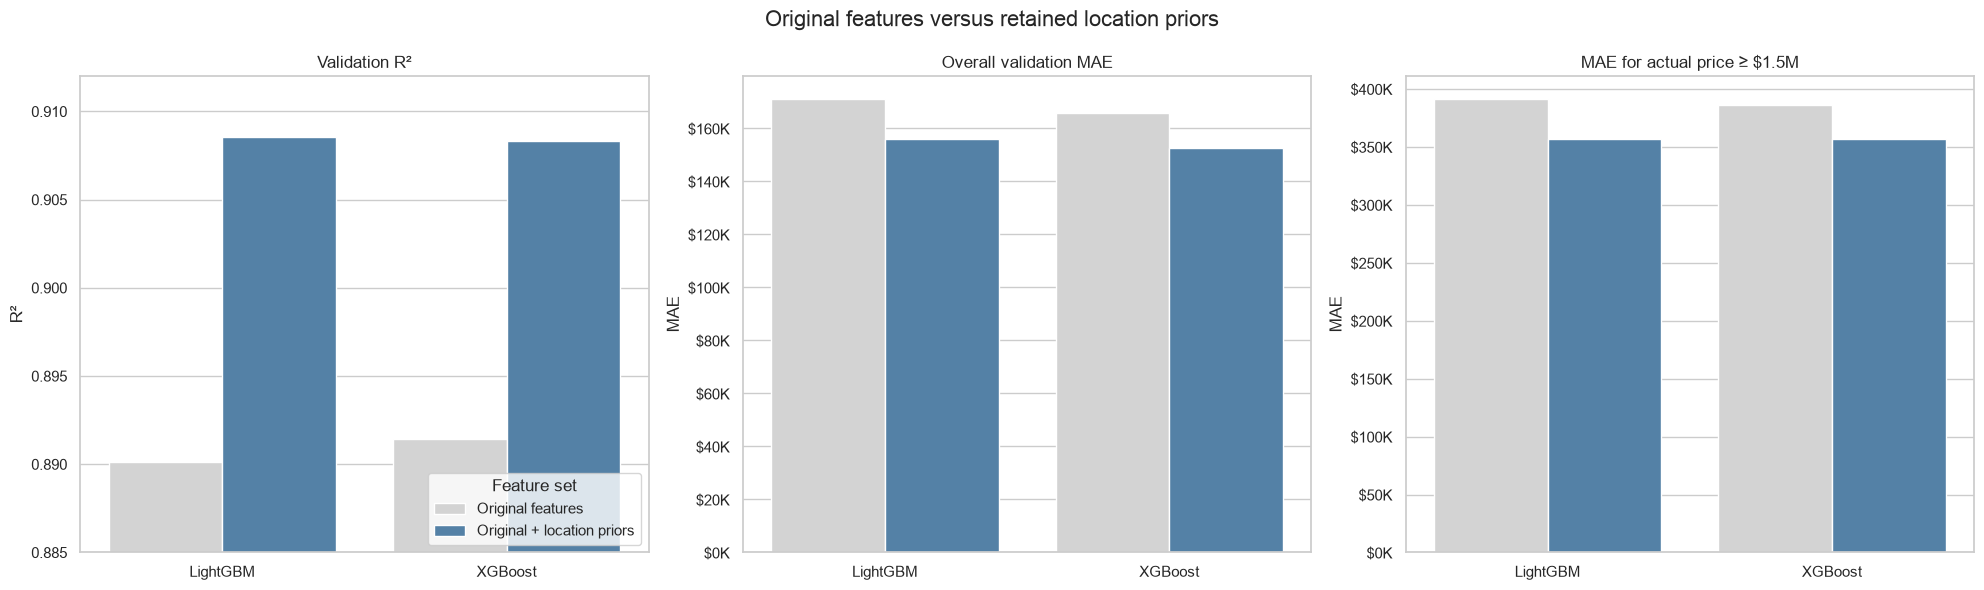

In [9]:
plot_data = results_df.copy()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(
    data=plot_data, x="model", y="validation_r2", hue="feature_set",
    hue_order=["Original features", "Original + location priors"],
    ax=axes[0], palette=["lightgray", "steelblue"],
)
axes[0].set_title("Validation R²")
axes[0].set_xlabel("")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0.885, 0.912)

sns.barplot(
    data=plot_data, x="model", y="validation_mae", hue="feature_set",
    hue_order=["Original features", "Original + location priors"],
    ax=axes[1], palette=["lightgray", "steelblue"], legend=False,
)
axes[1].set_title("Overall validation MAE")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1000:.0f}K"))

sns.barplot(
    data=plot_data, x="model", y="mae_1_5m_plus", hue="feature_set",
    hue_order=["Original features", "Original + location priors"],
    ax=axes[2], palette=["lightgray", "steelblue"], legend=False,
)
axes[2].set_title("MAE for actual price ≥ $1.5M")
axes[2].set_xlabel("")
axes[2].set_ylabel("MAE")
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1000:.0f}K"))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="Feature set", loc="lower right")
for axis in axes:
    axis.grid(axis="x", visible=False)

fig.suptitle("Original features versus retained location priors", fontsize=16)
fig.tight_layout()
fig.savefig(COMPARISON_PLOT_FILE, dpi=180, bbox_inches="tight")
plt.show()

## Save the best validation model and scoring context

The artifact includes the trained model, full-training administrative lookup tables, and the fitted nearest-neighbor reference set required to construct the same features for a new property. This remains a validation-selected artifact, not a final test-approved model.

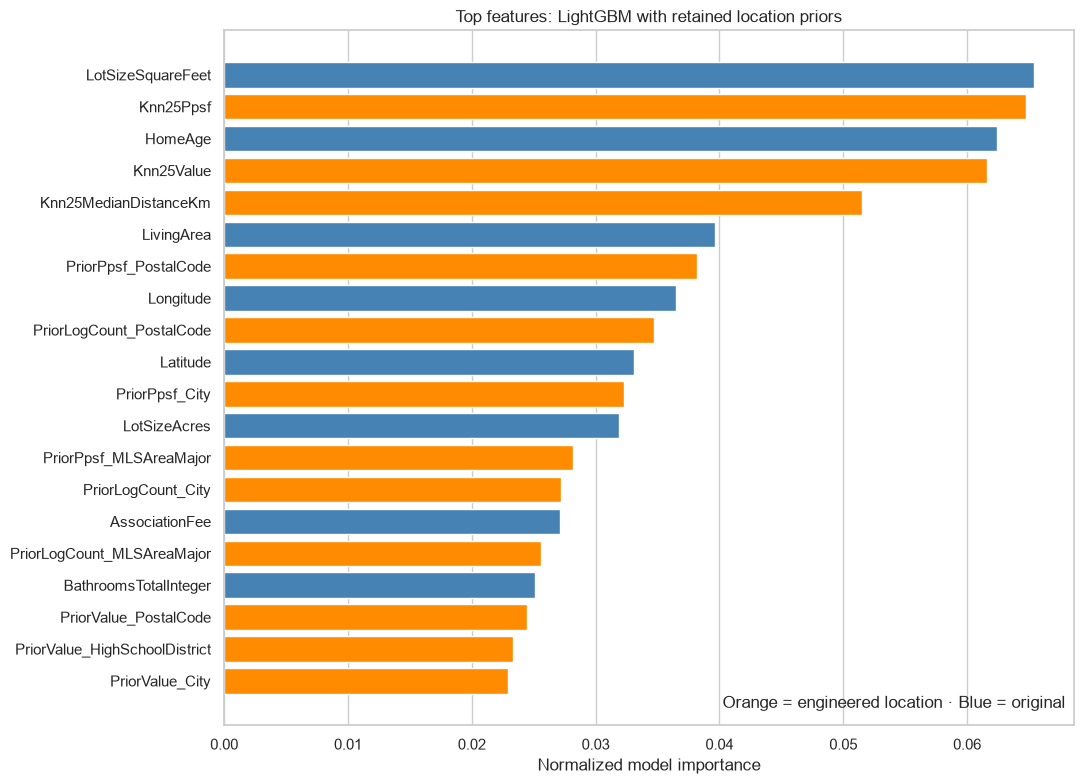

,feature,importance,location_engineered
0,numeric__LotSizeSquareFeet,0.0654,False
1,numeric__Knn25Ppsf,0.0647,True
2,numeric__HomeAge,0.0624,False
3,numeric__Knn25Value,0.0616,True
4,numeric__Knn25MedianDistanceKm,0.0515,True
5,numeric__LivingArea,0.0396,False
6,numeric__PriorPpsf_PostalCode,0.0381,True
7,numeric__Longitude,0.0365,False
8,numeric__PriorLogCount_PostalCode,0.0347,True
9,numeric__Latitude,0.0331,False


In [10]:
best_row = results_df.iloc[0]
best_key = (best_row["model"], best_row["feature_set"])
best_pipeline = artifacts[best_key]

administrative_prior_artifacts = {}
for group_column in PRIOR_GROUPS:
    prior_map, count_map, global_prior = fit_smoothed_prior(train_features, group_column)
    administrative_prior_artifacts[group_column] = {
        "ppsf_prior": prior_map.to_dict(),
        "group_count": count_map.to_dict(),
        "global_ppsf_prior": float(global_prior),
    }

joblib.dump({
    "pipeline": best_pipeline,
    "model": best_row["model"],
    "feature_set": best_row["feature_set"],
    "feature_spec": FEATURE_SETS[best_row["feature_set"]],
    "upper_cutoff": UPPER_CUTOFF,
    "administrative_prior_artifacts": administrative_prior_artifacts,
    "administrative_prior_smoothing": PRIOR_SMOOTHING,
    "knn_scoring_artifact": knn_scoring_artifact,
    "selection_metric": "validation_r2",
    "note": "Validation-selected artifact; May 2026 test not evaluated.",
}, MODEL_FILE)

feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance_values = best_pipeline.named_steps["model"].feature_importances_.astype(float)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values,
})
importance_df["importance"] /= importance_df["importance"].sum()
importance_df["location_engineered"] = importance_df["feature"].apply(
    lambda name: any(feature in name for feature in ADMIN_PRIOR_FEATURES + KNN_PRIOR_FEATURES)
)
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
importance_df.to_csv(IMPORTANCE_FILE, index=False)

top_importance = importance_df.head(20).sort_values("importance").copy()
top_importance["display_feature"] = (
    top_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("boolean__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)
colors = top_importance["location_engineered"].map({True: "darkorange", False: "steelblue"})
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top_importance["display_feature"], top_importance["importance"], color=colors)
ax.set_title(f"Top features: {best_key[0]} with retained location priors")
ax.set_xlabel("Normalized model importance")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.text(
    0.99, 0.02, "Orange = engineered location · Blue = original",
    transform=ax.transAxes, ha="right", va="bottom",
)
fig.tight_layout()
fig.savefig(IMPORTANCE_PLOT_FILE, dpi=180, bbox_inches="tight")
plt.show()

importance_df.head(25)

## Final recommendation

In [11]:
final_rows = results_df[results_df["feature_set"] == "Original + location priors"].copy()
summary_table = final_rows[[
    "model", "validation_r2", "r2_change_vs_original",
    "validation_mae", "mae_change_vs_original", "mae_1_5m_plus",
]].sort_values("validation_r2", ascending=False)
display(summary_table)

print(f"Best validation configuration: {best_row['model']} + retained location priors")
print(f"Validation R²: {best_row['validation_r2']:.4f}")
print(f"Validation MAE: ${best_row['validation_mae']:,.0f}")
print(f"R² change from original features: {best_row['r2_change_vs_original']:+.4f}")
print(f"MAE change from original features: ${best_row['mae_change_vs_original']:+,.0f}")
print(f"$1.5M+ MAE: ${best_row['mae_1_5m_plus']:,.0f}")
print("\nKeep the administrative and 25-nearest-comparable priors. No other experimental feature code is retained in this notebook.")
print("Freeze the feature strategy before evaluating May 2026.")

,model,validation_r2,r2_change_vs_original,validation_mae,mae_change_vs_original,mae_1_5m_plus
0,LightGBM,0.9085,0.0184,"156,084.2870","-15,051.7041","356,512.3614"
1,XGBoost,0.9083,0.0169,"152,769.1853","-12,985.4899","356,666.2743"


Best validation configuration: LightGBM + retained location priors
Validation R²: 0.9085
Validation MAE: $156,084
R² change from original features: +0.0184
MAE change from original features: $-15,052
$1.5M+ MAE: $356,512

Keep the administrative and 25-nearest-comparable priors. No other experimental feature code is retained in this notebook.
Freeze the feature strategy before evaluating May 2026.
